In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [4]:
X,y = make_moons(100,noise=0.25,random_state = 42)

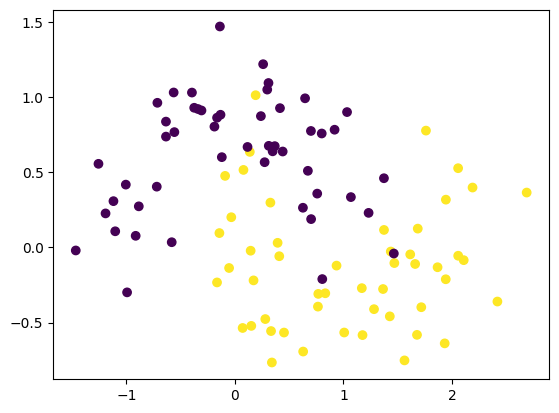

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [7]:
model = Sequential()
model.add(Dense(128,input_dim = 2,activation = 'relu'))
model.add(Dense(128,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
adam = Adam(learning_rate=0.01)
model.compile(loss = 'binary_crossentropy',optimizer = adam,metrics = ['accuracy'])
history = model.fit(X,y,epochs = 2000,validation_split=0.2,verbose = 1)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.6250 - loss: 0.6153 - val_accuracy: 0.8000 - val_loss: 0.4700
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8375 - loss: 0.3724 - val_accuracy: 0.8000 - val_loss: 0.4458
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8750 - loss: 0.3184 - val_accuracy: 0.8000 - val_loss: 0.4529
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8750 - loss: 0.2887 - val_accuracy: 0.8000 - val_loss: 0.4854
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8625 - loss: 0.2932 - val_accuracy: 0.8000 - val_loss: 0.4522
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8750 - loss: 0.2744 - val_accuracy: 0.8000 - val_loss: 0.3720
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9000 - loss: 0.2722 - val_accuracy: 0.8500 - val_loss: 0.3574
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9000 - loss: 0.2547 - val_accuracy: 0.8000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


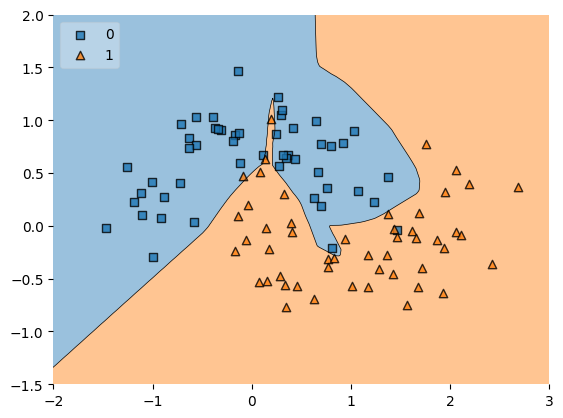

In [11]:
plot_decision_regions(X,y.astype('int'),clf = model,legend = 2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

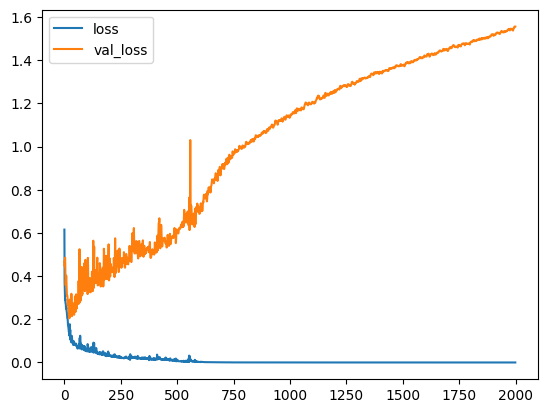

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'])
plt.show()

In [18]:
model2 = Sequential()

model2.add(Dense(128,input_dim = 2,activation = 'relu', kernel_regularizer=tensorflow.keras.regularizers.l2(0.03))) ### The value 0.03 inside the l2 represents the value of Lmanda
model2.add(Dense(128,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(1,activation = 'sigmoid'))
model2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
adam = Adam(learning_rate = 0.01)
model2.compile(loss = 'binary_crossentropy',optimizer = adam,metrics = ['accuracy'])
history2 = model2.fit(X,y,epochs = 2000,validation_split=0.2,verbose = 1)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.6625 - loss: 5.7239 - val_accuracy: 0.8000 - val_loss: 3.9264
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8000 - loss: 3.4065 - val_accuracy: 0.8000 - val_loss: 2.3181
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7875 - loss: 1.9774 - val_accuracy: 0.8000 - val_loss: 1.4191
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8250 - loss: 1.2033 - val_accuracy: 0.7500 - val_loss: 1.0122
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8000 - loss: 0.8686 - val_accuracy: 0.7500 - val_loss: 0.8378
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8125 - loss: 0.7565 - val_accuracy: 0.8000 - val_loss: 0.8080
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8250 - loss: 0.7470 - val_accuracy: 0.7500 - val_loss: 0.8667
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8125 - loss: 0.7741 - val_accuracy: 0.8000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


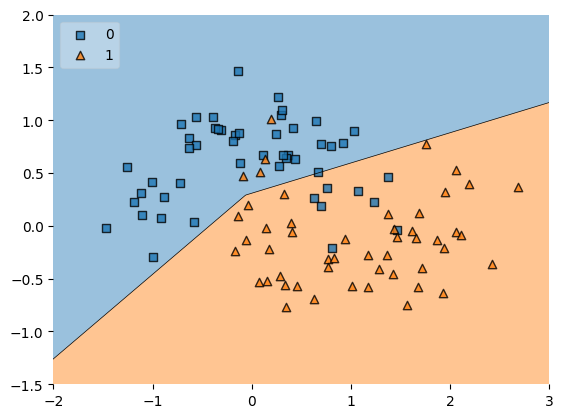

In [20]:
plot_decision_regions(X,y.astype('int'),clf = model2,legend = 2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

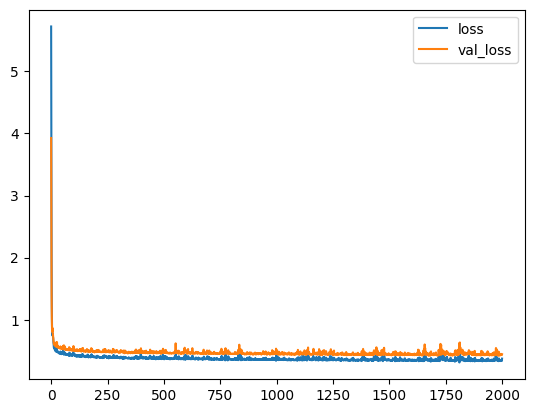

In [23]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(['loss','val_loss'])
plt.show()

###Model Weights

In [27]:
## We can use model.get_weights to access all the weights
model.get_weights()

[array([[-0.6858329 ,  0.06947498, -0.03056134,  1.43293   , -1.0174644 ,
          0.29881746, -0.18586436,  0.6084809 ,  0.05080133, -0.10335645,
          0.2915082 , -0.5351887 , -0.8381431 , -0.976372  ,  0.02226155,
         -0.04640058,  0.15458237,  1.7635524 ,  0.26992172,  0.07264768,
         -0.70640856,  0.28180498,  0.2588849 , -0.4290908 , -0.06002266,
          1.4279124 , -0.99182683,  0.1104001 , -0.09616869,  0.9092647 ,
          0.07937944,  0.14589147, -0.71994275, -0.11621375, -0.65851915,
         -0.80481976, -0.63707864,  0.14723372,  0.09755001, -0.1366394 ,
         -0.23379144, -0.53222746, -0.6572867 ,  0.11373559, -0.38487923,
         -0.33913928, -0.63056064,  0.6935163 ,  0.2356767 , -0.23036844,
         -0.6729393 ,  0.8944434 , -0.52701837,  0.32358208, -0.01813016,
          0.22809124, -0.62598747, -0.39766717, -0.45377022,  0.08925854,
         -0.6849496 , -0.5176784 ,  0.45785055,  0.7796652 , -0.08352502,
          0.2748831 ,  0.51021457, -0.

In [24]:
model1_weight_layer1 = model.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

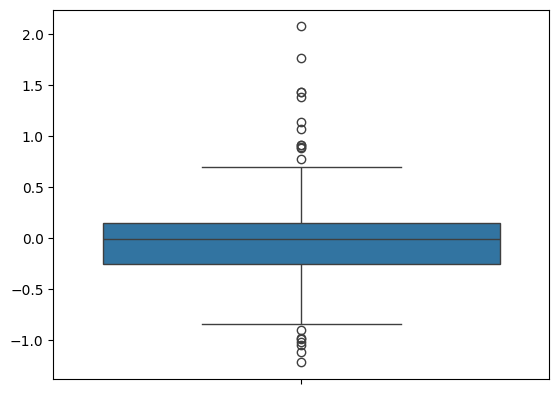

In [25]:
sns.boxplot(model1_weight_layer1)

<Axes: >

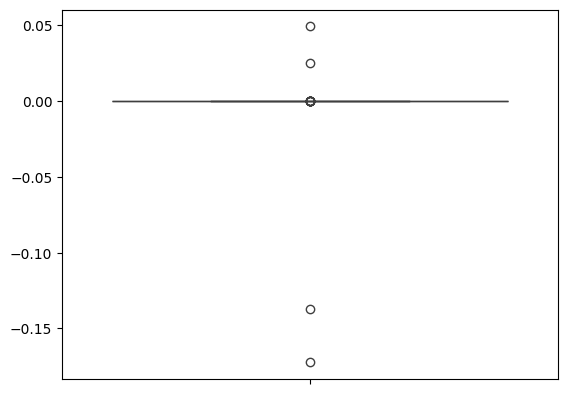

In [28]:
sns.boxplot(model2_weight_layer1)
## amost all the weights got delayed and lie around 0

In [29]:
print(model1_weight_layer1.min())
print(model1_weight_layer1.max())

-1.2170835
2.0755389


In [30]:
print(model2_weight_layer1.min())
print(model2_weight_layer1.max())

-0.17237802
0.04937944


## Plotting the Probability Density curves (PDF Curves)

#### The curve in Orange color is the curve with which the model is trained using the Regularization

#### Therefore Most of the weight sin case of the Orange Color lie near the Origin (Close to 0)

#### Whereas the weights are spreaded over the curve without regularization


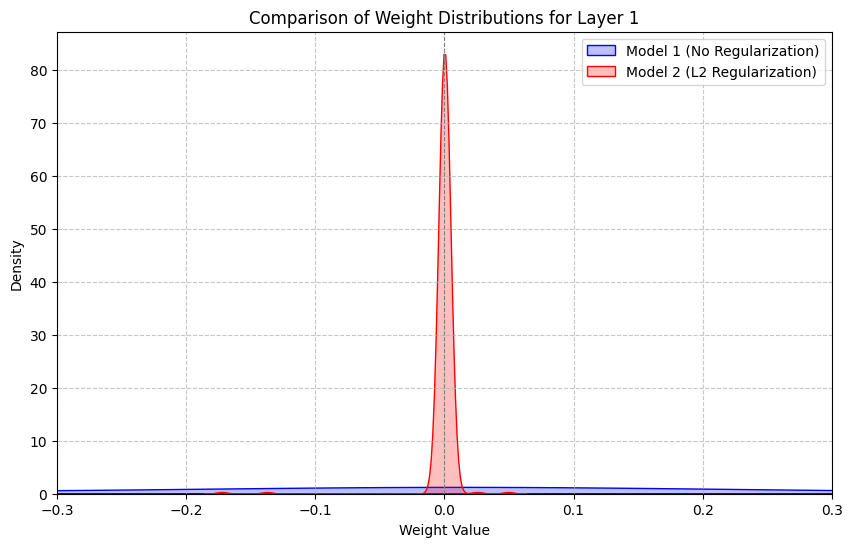

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.kdeplot(model1_weight_layer1, color='blue', fill=True, label='Model 1 (No Regularization)')
sns.kdeplot(model2_weight_layer1, color='red', fill=True, label='Model 2 (L2 Regularization)')

plt.title('Comparison of Weight Distributions for Layer 1')
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.3, 0.3) # Zoom in on the x-axis
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8) # Add a vertical line at x=0
plt.show()